In [1]:
import os, re, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
INPUT_DIR = '../affine_denoising_results'
SAVE_DIR = './equivariant_denoising_figures'
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
MODEL_DIRS = {
    "LPN": "lpn",
    "NE-LPN (By Design)": "ne_by_design",
    "NE-LPN (By Normalization Trick)": "ne_by_forward",
    "Scale-Equivariant LPN": "scale_by_design",
}

In [4]:
def _load_image(path):
    return np.array(Image.open(path))

In [5]:
def _list_indices_for(folder, stem="denoised"):
    """All indices i with files like '{stem}_{i}.png' in folder."""
    if not os.path.isdir(folder):
        return []
    idxs = []
    for fname in os.listdir(folder):
        m = re.match(rf"{re.escape(stem)}_(\d+)\.png$", fname)
        if m:
            idxs.append(int(m.group(1)))
    return sorted(idxs)

In [6]:
def _scale_dir_candidates(alpha):
    """Try several representations to match 'scale_*' dir names."""
    cands = [
        f"scale_{alpha:g}",
        f"scale_{alpha:.2f}",
        f"scale_{alpha:.6f}",
        f"scale_{alpha}",
    ]
    seen, out = set(), []
    for c in cands:
        if c not in seen:
            out.append(c); seen.add(c)
    return out

In [7]:
def _resolve_scale_dir(base_dir, alpha):
    for cand in _scale_dir_candidates(alpha):
        full = os.path.join(base_dir, cand)
        if os.path.isdir(full):
            return full
    return None

In [8]:
def _common_indices_for_alpha(alpha_dirs_by_model):
    """Intersection of available denoised indices across all model dirs for this alpha."""
    sets = []
    for a_dir in alpha_dirs_by_model.values():
        sets.append(set(_list_indices_for(a_dir, stem="denoised")))
    if not sets:
        return set()
    common = sets[0].copy()
    for s in sets[1:]:
        common &= s
    return common

In [9]:
def build_affine_grid(
    mode,
    alpha_scales,
    indices_by_alpha=None,     # dict like {1.0: 0, 0.75: 3, ...}; if None, auto-pick per alpha
    model_dirs=MODEL_DIRS,
    auto_pick="first",         # "first" or "random"
    random_seed=0,
    require_gt=False           # if True, raise if any chosen row lacks GT; else omit GT column
):
    """
    Single figure: rows = alpha values (top->bottom), columns = [GT (if present)] + per-model denoised.
    Each row can use a different image index.

    - mode: "brighten" or "darken"
    - alpha_scales: list of alphas, e.g., [1.0, 0.75, 0.5, 0.25]
    - indices_by_alpha: optional dict mapping alpha->index to use on that row
    - auto_pick: how to choose index if not provided: "first" or "random"
    - require_gt: if True, enforce GT exists for ALL rows; else drop GT column entirely if any row lacks it
    """
    rng = random.Random(random_seed)

    mode_root = os.path.join(INPUT_DIR, mode)
    if not os.path.isdir(mode_root):
        raise FileNotFoundError(f"Mode directory not found: {mode_root}")

    # Resolve per-alpha per-model dirs and figure out the index to use for each row
    per_alpha = []  # list of dicts: {"alpha": a, "dirs": {model_name: path}, "idx": i}
    for a in alpha_scales:
        dirs_for_models = {}
        for model_name, subdir in model_dirs.items():
            base = os.path.join(mode_root, subdir)
            a_dir = _resolve_scale_dir(base, a)
            if a_dir is None:
                raise FileNotFoundError(
                    f"Missing alpha dir for {model_name}, mode={mode}, alpha={a} under {base}"
                )
            dirs_for_models[model_name] = a_dir

        # pick index for this alpha
        if indices_by_alpha is not None and a in indices_by_alpha:
            idx = indices_by_alpha[a]
            # Validate availability
            ok = all(os.path.exists(os.path.join(dirs_for_models[m], f"denoised_{idx}.png"))
                     for m in model_dirs.keys())
            if not ok:
                raise RuntimeError(f"Requested idx={idx} not available for ALL models at alpha={a}.")
        else:
            common = _common_indices_for_alpha(dirs_for_models)
            if not common:
                raise RuntimeError(f"No common denoised indices across models at alpha={a}.")
            idx = min(common) if auto_pick == "first" else rng.choice(sorted(list(common)))

        per_alpha.append({"alpha": a, "dirs": dirs_for_models, "idx": idx})

    # Decide GT column: require across ALL rows
    first_model = next(iter(model_dirs.keys()))
    def row_has_gt(row):
        gt_path = os.path.join(row["dirs"][first_model], f"transformed_{row['idx']}.png")
        return os.path.exists(gt_path)

    gt_rows = [row_has_gt(r) for r in per_alpha]
    if require_gt:
        if not all(gt_rows):
            missing = [(r["alpha"], r["idx"]) for r, has in zip(per_alpha, gt_rows) if not has]
            raise RuntimeError(f"GT missing for rows: {missing}. Set require_gt=False to omit GT column.")
        gt_exists_globally = True
    else:
        gt_exists_globally = all(gt_rows)  # only show GT column if it exists for every row

    # Build figure
    num_rows = len(per_alpha)
    num_cols = (1 if gt_exists_globally else 0) + len(model_dirs)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    if num_rows == 1:
        axs = np.expand_dims(axs, 0)

    col_titles = []
    col_map = {}
    col = 0
    if gt_exists_globally:
        col_titles.append("Transformed Input" if "transformed" in " ".join(os.listdir(per_alpha[0]['dirs'][first_model])) 
                        else "Ground Truth")
        col_map[col] = ("GT", None)
        col += 1

    for model_key in model_dirs.keys():
        # pretty display title for the legend/header only
        display = (model_key
                .replace("Equivariant", "Equivariant\n")
                .replace("(By", "\n(By"))
        col_titles.append(display)
        # store the *key* (not the display string) for filesystem lookup
        col_map[col] = ("MODEL", model_key)
        col += 1

    # Fill rows
    for r, row in enumerate(per_alpha):
        a = row["alpha"]; idx = row["idx"]; dirs_for_models = row["dirs"]
        ax_left = axs[r, 0]                      # leftmost axes in this row (GT or first model)
        ax_left.text(
            -0.14, 0.5,                          # a bit outside the left edge
            rf'$\alpha={a}$',                    # pretty math text; or f'α={a}'
            transform=ax_left.transAxes,
            fontsize=16, fontweight='bold',
            rotation=90, va='center', ha='center',
            clip_on=False                        # <-- important so it doesn't get clipped
        )

        for c in range(num_cols):
            what, key_or_none = col_map[c]
            if what == "GT":
                gt_path = os.path.join(dirs_for_models[first_model], f"transformed_{idx}.png")  # or gt_{idx}.png if that's what you saved
                img = _load_image(gt_path)
            else:
                model_key = key_or_none  # this is the dict key, not the display title
                den_path = os.path.join(dirs_for_models[model_key], f"denoised_{idx}.png")
                img = _load_image(den_path)
            axs[r, c].imshow(img); axs[r, c].axis('off')


    # Headers
    for j, title in enumerate(col_titles):
        axs[0, j].text(0.5, 1.08, title, transform=axs[0, j].transAxes,
                       fontsize=18, fontweight='bold', ha='center', va='bottom')
    #plt.suptitle(f"Mode: {mode}", fontsize=20, fontweight='bold', y=0.98)
    plt.subplots_adjust(top=0.9, left=0.05, right=0.98, bottom=0.05, hspace=0.1, wspace=0.1)
    plt.subplots_adjust(top=0.9, left=0.14, right=0.98, bottom=0.05, hspace=0.1, wspace=0.1)
    plt.savefig(os.path.join(SAVE_DIR, f"affine_denoising_{mode}.pdf"), bbox_inches='tight')
    plt.show()


In [10]:
alphas = [1.0, 0.75, 0.5, 0.25]

In [11]:
custom = {1.0: 0, 0.75: 1, 0.5: 2, 0.25: 3}

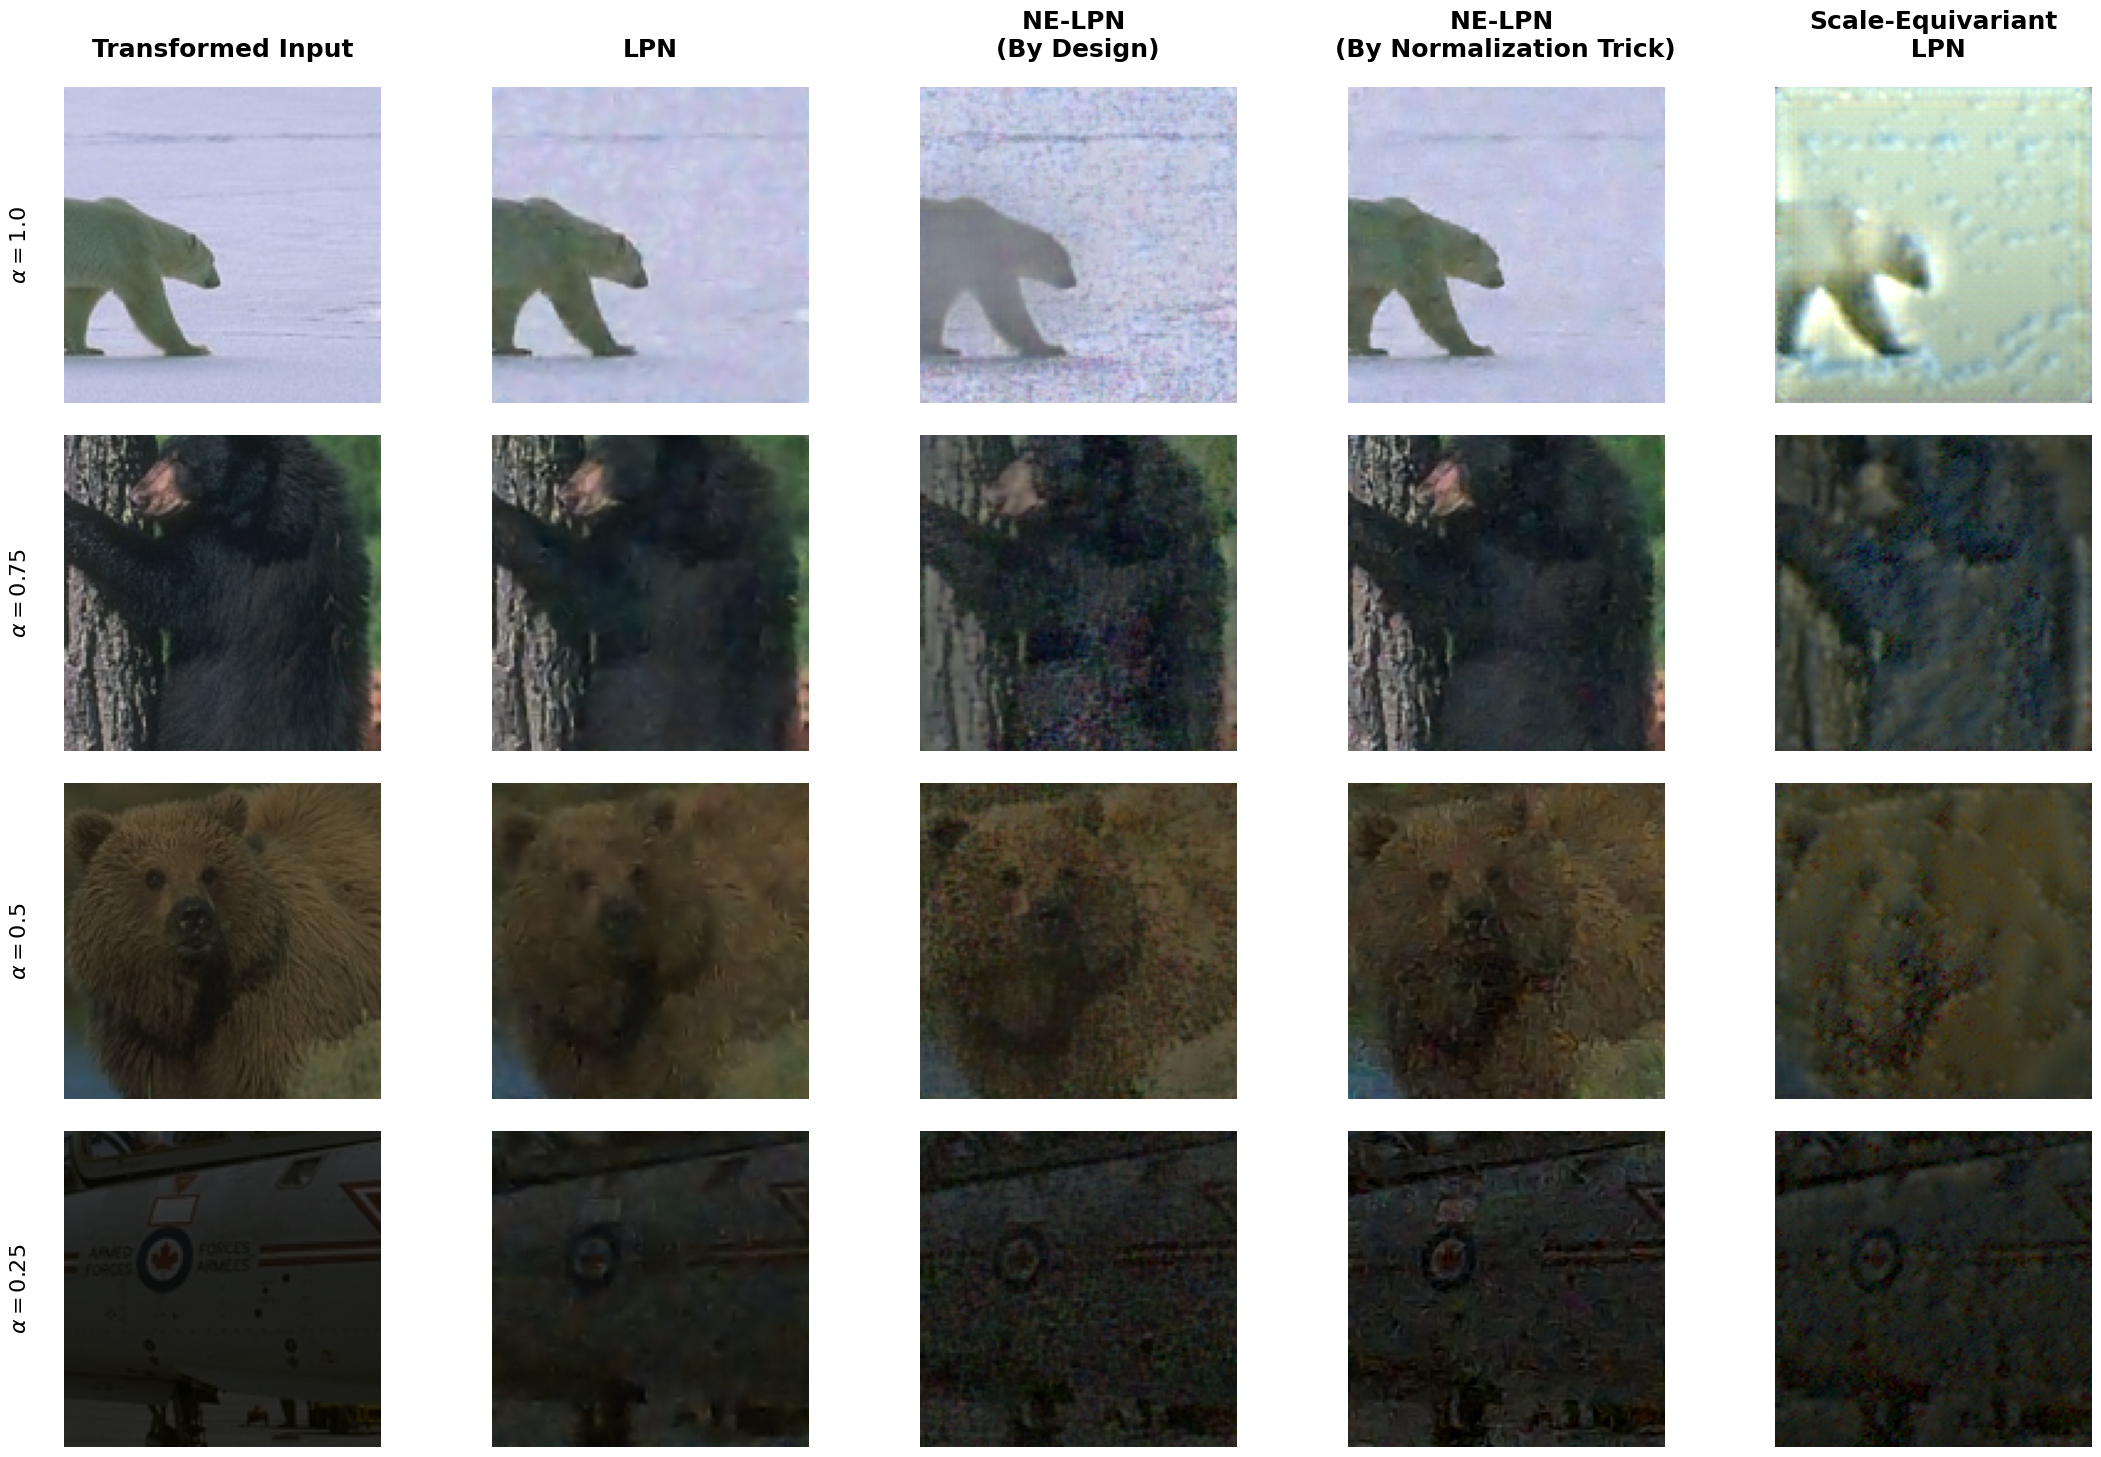

In [12]:
build_affine_grid(mode="darken", alpha_scales=alphas, indices_by_alpha=custom)

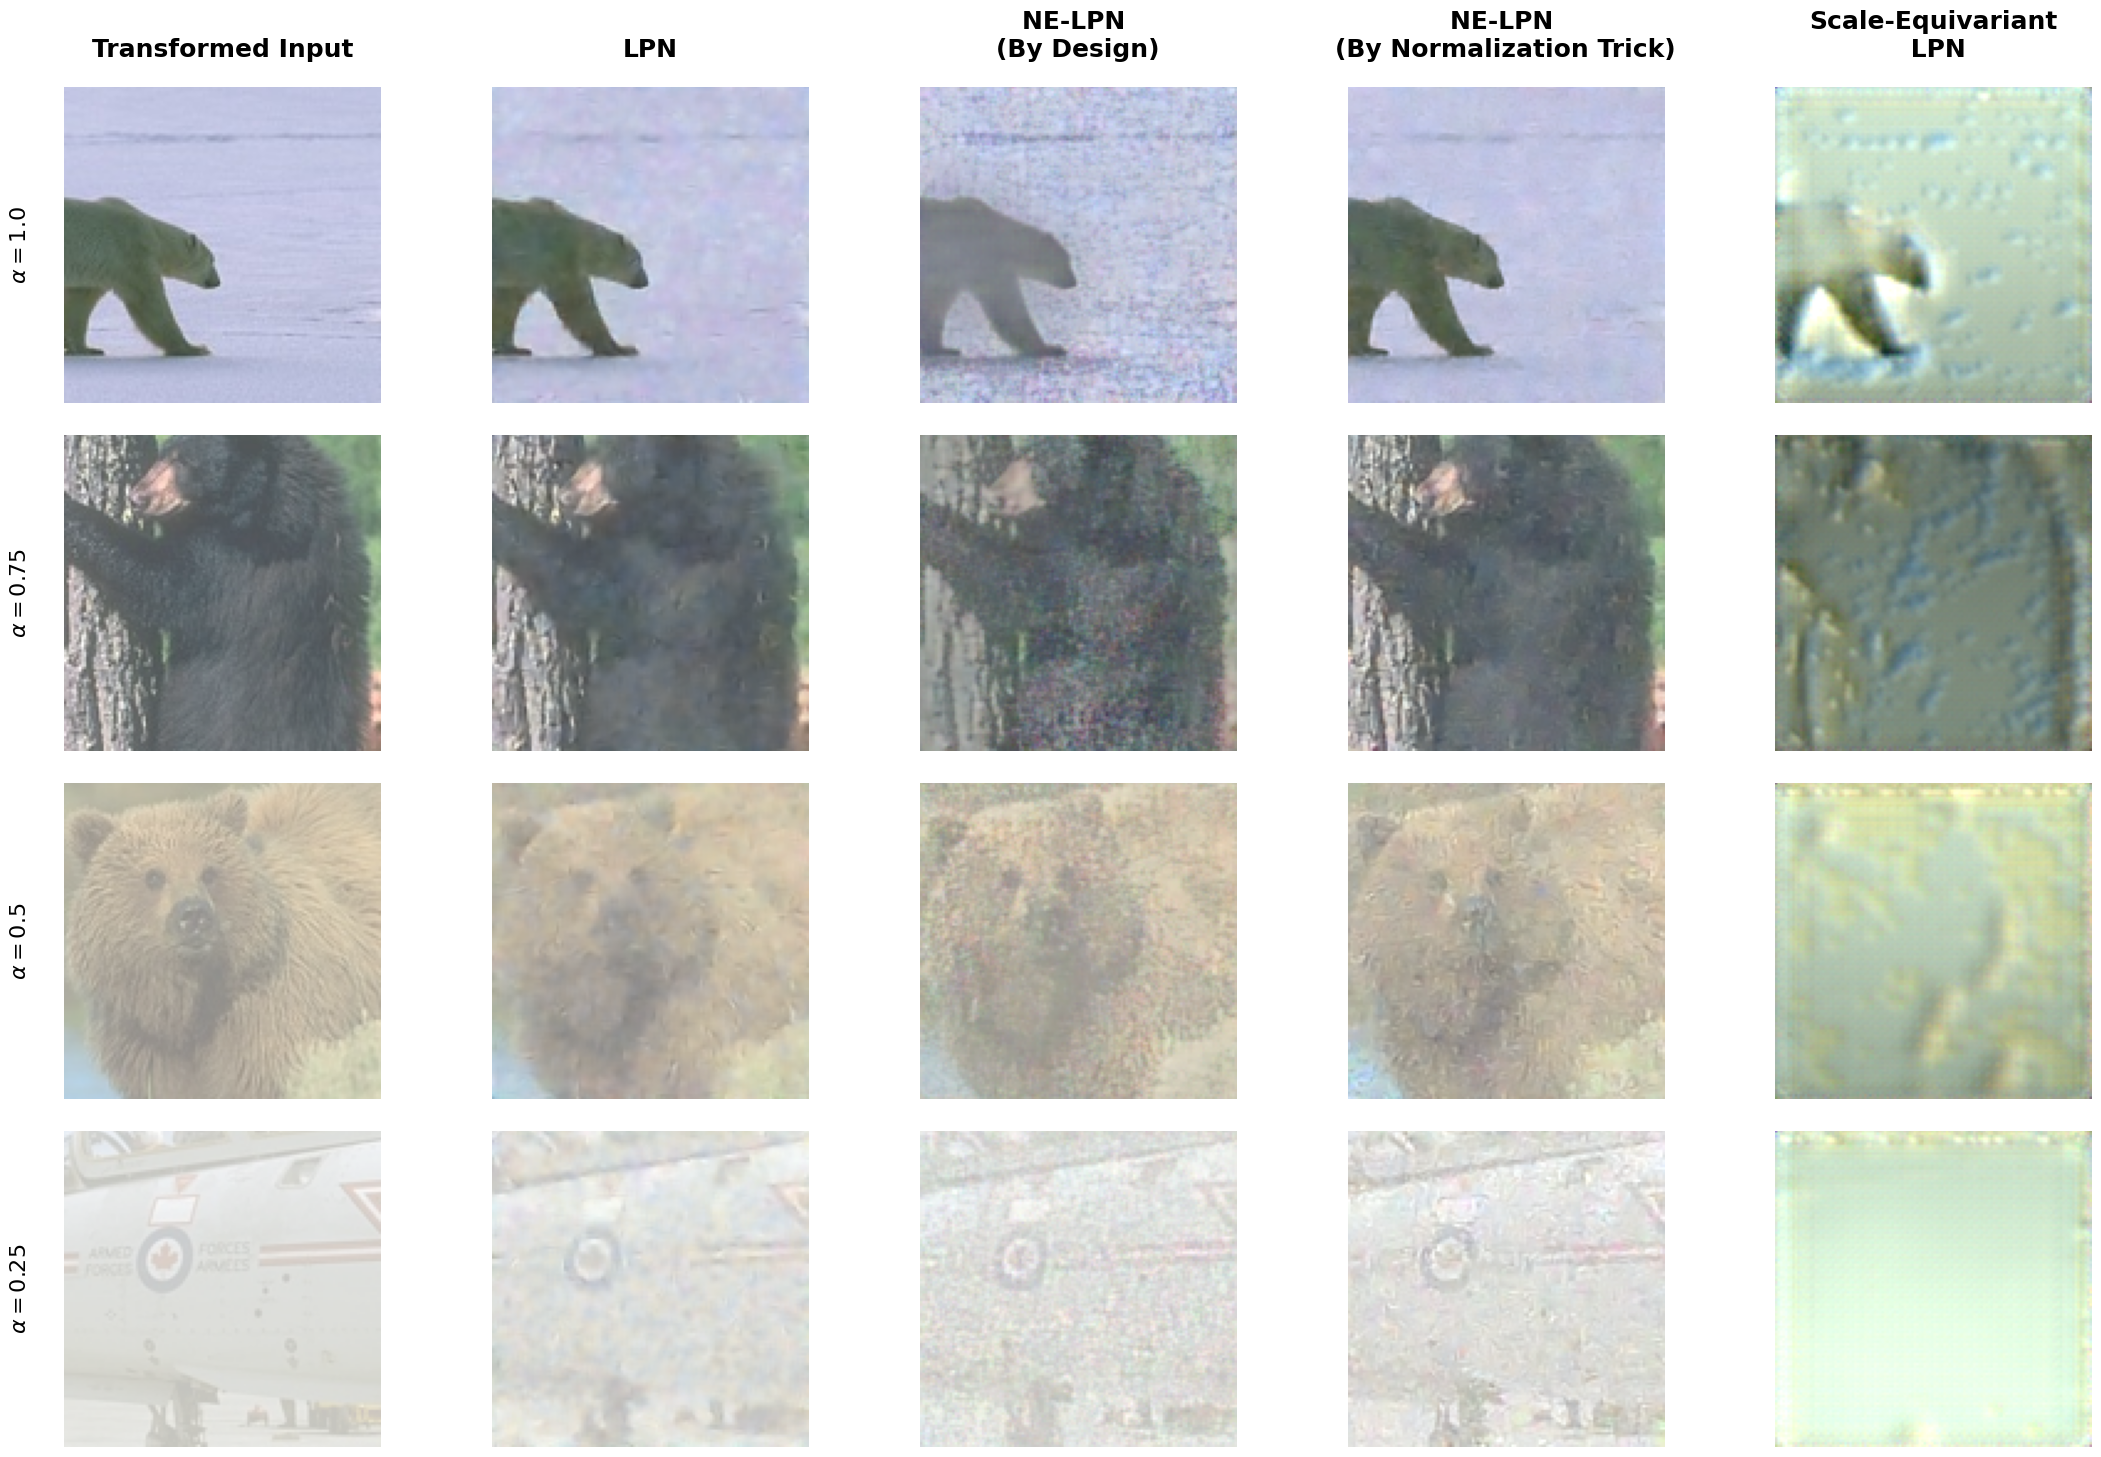

In [13]:
build_affine_grid(mode="brighten", alpha_scales=alphas, indices_by_alpha=custom)